# CFL Pipeline Example on MNIST Dataset 
-----------------
This notebook will show how to run a basic experiment using the `cfl` package. The experiment aims to show how CFL can aggregate hand-drawn digits into groups of numbers based on some effect variable.

Contents 
- Experiment Setup
- Data Generation
- CFL Pipeline
- Visualizing Results
- Quantifying Error


## Experiment Setup

This is a demonstration of the CFL pipeline on the MNIST dataset. We generate data in the following way:

Consider the dataset, which are are images $x$ from 0 to 9. The true macrovariables $X$ are states $A, B, C$ for which numbers 0-3 are in class $A$, 4-6 in class $B$, and 7-9 in class $C$. For some number $x$ from the data set, we have affect variable $Y\in \{\alpha, \beta\}$, which obey the following distribution.

$P(\alpha | A) = 0.95,P(\beta | A) =0$

$P(\alpha | B) =0,P(\beta | B) =0.95$

$P(\alpha | C) =0.5,P(\beta | C) =0.5$

Below we have a visual representation of cause and effect macrovariables. 

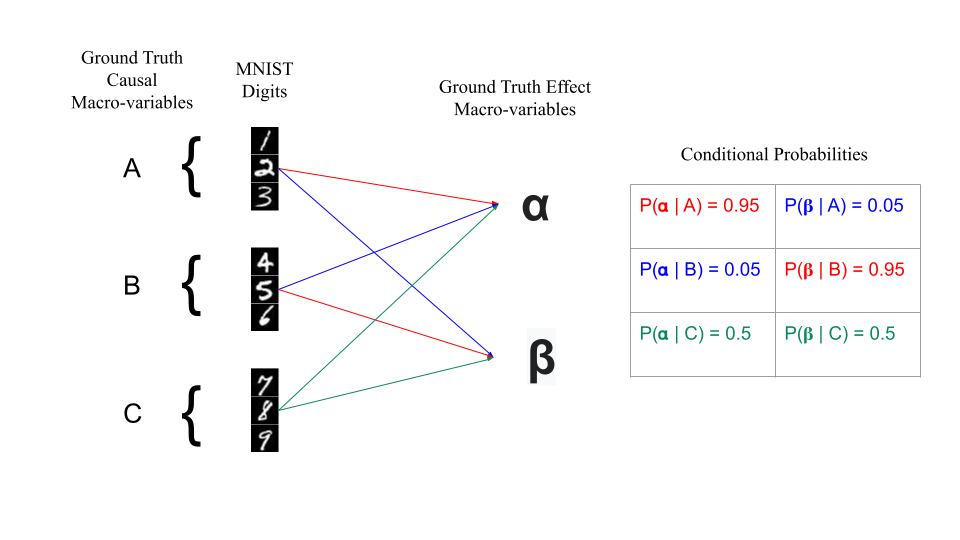

Above we see the setup for a pair of cause and effect variables that use the MNIST data . We have as input MNIST digits from zero to nine. In this set-up, the digits are grouped into three causal classes, with digits one through three, four through six, and seven through nine belonging to causal classes A, B, and C respectively. These classes dictate the probability of observing effect variables alpha versus beta. As can be seen in the diagram, class A is primarily associated with alpha and class B is primarily associated with beta, with slight deviations. Class C will produce either alpha or beta with equal probabilities. Thus, from raw image data, CFL must be able to discern the macro-variable classes A, B, C that “cause” an outcome value of alpha or beta.

<!-- We are not aggregating on the effect side -->


## Data Generation
We first import the MNIST training and test sets. Note that in our example, we will be discarding 0 images because we want each class to contain the same number of images. Also to enhance learning, we shall scale the intensities down to a [0,1] range.

In [24]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# Keep only data 1-9

X_train = X_train[Y_train != 0]
Y_train = Y_train[Y_train != 0]

X_test = X_test[Y_test != 0]
Y_test = Y_test[Y_test != 0]


In [25]:
print('MNIST Dataset Shape:')
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(Y_train.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(Y_test.shape))

MNIST Dataset Shape:
X_train: (54077, 28, 28)
Y_train: (54077,)
X_test:  (9020, 28, 28)
Y_test:  (9020,)


In [26]:
# We must divide convert the image values from [0, 255] to [0, 1] to speed up training

MAX_RGB = 255

X_train = np.true_divide(X_train, MAX_RGB)
X_test = np.true_divide(X_test, MAX_RGB)

We shall now generate effect classes alpha and beta according to causal classes A, B, C, and their correpsonding distributions. Refer to the setup described previously.

In [27]:
from cfl import util
import random

# Generate target (Y) data. Here 'a' and 'b' are represent alpha and beta

targets = ['alpha', 'beta']
class_A = [1, 2, 3]
class_B = [4, 5, 6]
class_C = [7, 8, 9]
distributions = [[0.95, 0.05], [0.05, 0.95], [0.5, 0.5]]

'''
Returns a distribution depending on the causal class of the input value
'''
def get_distribution(val):
    if val in class_A:
        return distributions[0]
    elif val in class_B:
        return distributions[1]
    else:
        return distributions[2]

'''
For every data point given, draw from its distribution and return an array of target variables
'''
def generate_target(data):
    target = []
    for val in data:
        target += (random.choices(targets, get_distribution(val)))
    return np.array(target)



In [28]:
# Examples of data generation. We should observe over repeated runs that images numbered 1-3 tend toward alpha,
# 4-6 tend toward beta, and 7-9 should be a uniform mix.

for i in range(1, 10):
    print('Image number: {}\nTarget value: {}\n'.format(i, generate_target([i])))

Image number: 1
Target value: ['alpha']

Image number: 2
Target value: ['alpha']

Image number: 3
Target value: ['alpha']

Image number: 4
Target value: ['beta']

Image number: 5
Target value: ['beta']

Image number: 6
Target value: ['beta']

Image number: 7
Target value: ['alpha']

Image number: 8
Target value: ['beta']

Image number: 9
Target value: ['beta']



## CFL Pipeline

Some manipulation is required to make the input valid for a CNN. Causal variables are given an additional dimension to represent channel (there is only one channel for black and white images). Effect variables are one-hot-encoded into distinct categorical classes.

In [29]:
#reformat X and Y into the right shape for the neural net 
X = np.expand_dims(X_train, -1)
Y = util.data_processing.one_hot_encode(generate_target(Y_train), targets)

print(X.shape[1:])
print(Y.shape[1:])

(28, 28, 1)
(2,)



Now we define the parameters of CFL. We must provide three dictionaries: information about the dataset, parameters for the CNN, and clustering parameters.

The CNN is used as a conditional density estimator (CDE) and the clustering will cluster values on the CDE to form causal classes.

In [30]:
#import standard packages 
import numpy as np #needed for reshaping arrays 
import matplotlib.pyplot as plt #for rendering plots


# you can also import specific files, functions, or classes
# into the local namespace 
from cfl.experiment import Experiment

# or rename modules for brevity 
# TODO refactor
from cfl.visualization_methods import visual_bars_vis as vis

As can be seen below in the model summary, the CNN contains two convolutional layers with intermittent pooling layers. There is a single hidden layer with 500 dense units, and between all layers we use softmax activation functions. The output layer is 2 dimensional, representing probabalities of two classes alpha and beta.

For more info on Tensorflow CNN refer to:
https://www.tensorflow.org/tutorials/images/cnn

To form causal classes, we will also be using Kmeans clustering with 3 clusters for classes A, B, C.

In [31]:

data_info = { 'X_dims' : X.shape, 
              'Y_dims' : Y.shape, 
              'Y_type' : 'categorical' } 



# CDE parameters
CNN_params = { # parameters for model creation
                'filters'         : [32, 16],
                'input_shape'     : (28, 28, 1),
                'kernel_size'     : [(3, 3)] *2, 
                'pool_size'       : [(2, 2)] *2, 
                'padding'         : ['same'] *2,
                'conv_activation' : ['softmax', 'softmax'],
                'dense_units'     : 500,
                'dense_activation' : 'softmax',
                'output_activation': 'softmax',
    
                # parameters for training
                    'batch_size'  : 128,
                    'n_epochs'    : 30,
                    'optimizer'   : 'adam',
                    'opt_config'  : {},
                    'verbose'     : 2,
                    'weights_path': None,
                    'loss'        : 'categorical_crossentropy',
                    'show_plot'   : True,
                    'standardize' : False,
                    'best'        : True
              }

cluster_params = {  'n_Xclusters' : 3,
                    'n_Yclusters' : 2,
                 }   
                            
block_names = ['CondExpCNN', 'Kmeans']
block_params = [CNN_params, cluster_params]

my_exp = Experiment(X_train=X, Y_train=Y, data_info=data_info, block_names=block_names, block_params=block_params, blocks=None, results_path='results/mnist')

my_exp.blocks[0].model.summary()

All results from this run will be saved to results/mnist/experiment0056


AssertionError: Kmeans has not been added to BLOCK_KEY yet. Please do so before proceeding. Note: this is a temporary system until we set up Block registration.

We shall now "train" our CFL experiment. At this step, both CDE and clustering models are trained. First the data is fed through the CNN to train the CDE, then the clustering model is trained on the CDE.

In [ ]:
results = my_exp.train()

Now that our conditional density estimator is trained, we can make predictions on a test dataset. We shall generate the test set in the same manner as the training set before.

In [ ]:
# Using previous functions to create test data

X_new = np.expand_dims(X_test, -1)

Y_truth = generate_target(Y_test)
Y_new = util.data_processing.one_hot_encode(Y_truth, targets)

In [ ]:
# Using saved experiment, we will make predictions on test data set

my_exp.add_dataset(X=X_new, Y=Y_new, dataset_name='dataset_test')
results_new = my_exp.predict('dataset_test')


## Visualizing Results

Below we visualize predictions on a few examples. We can observe that these classes should contain numbers that correspond to causal classes A, B, and C.

In [ ]:
# Visualization X classes
# We give as input the test data, output shape, number of examples, and predicted labels
vis.viewImagesAndLabels(X_test, im_shape=(10,10), n_examples=5, x_lbls=results_new['Kmeans']['x_lbls'])

In [ ]:
# Visualization Y classes

# Probably remove
# vis.viewImagesAndLabels(X_test, im_shape=(10,10), n_examples=5, x_lbls=results_new['Kmeans']['y_lbls'])

In [ ]:
# from cfl.cluster_methods.kmeans import KMeans

# # create a number of Kmeans objects with different Ks 
# k_range = range(2, 8)

# kmeans_l = []
# for n_clusters in k_range:
#     params = {'n_Xclusters': n_clusters, 'n_Yclusters': 2} 
#     kmeans_obj = KMeans('Kmeans', data_info, params, random_state=143)
#     kmeans_l.append(kmeans_obj)

# data = Dataset(X_new, Y_new)

# # trained all the data on the kmeans
# x_lbls_L = []
# for kmeans_obj in kmeans_l: 
#     cluster_results = kmeans_obj.train(data, results_new['CondExpCNN'])
#     x_lbls_L.append(cluster_results['x_lbls'])

In [ ]:
# from cfl.visualization_methods import clustering_to_sankey as sk

# import plotly.graph_objects as go

# link, label = sk.convert_lbls_to_sankey_nodes(x_lbls_L)
# # plot
# fig = go.Figure(data=
#           [go.Sankey(node = dict(pad = 15, thickness=20, label = label, color =  "blue"),
#                      link = link)])
    
# fig.update_layout(title_text="MNIST Clustering, with 2 to 7 Clusters", font_size=10)
# fig.show()


Below we have four histograms. A CFL conditional density estimator (CDE) will take as input an image, and it will output the probability of belonging to a class. Below we fix this class to be alpha (also showing beta would be redundant because it is the complement). For every plot, the x-axis represents the the probability of belonging to class alpha, and the y-axis is the number of images that the CDE assigns some probability.


In [ ]:
import matplotlib.patches as mpatches

'''
Helper function used to partition a list of probabilities (CDE predictions) according to whether
the true values are contained within certain classes called truth_variables. Returns a partitioned array.
'''
def partition(probs, truth, truth_variables):
    result = []
    for var in truth_variables:
        result.append(probs[np.isin(truth, var)])
    return np.array(result, dtype=object)

'''
Paritions predicted CDE probabilites along classes A, B, and C
'''
def partition_cause_class(probs, truth):
    return partition(probs, truth, [class_A, class_B, class_C])

# Maybe unecessary

# def partition_learned_cause(probs, truth):
#     return partition(probs, truth, [[0],[1],[2]])

# def partition_effect_class(probs, truth):
#     return partition(probs, truth, [['alpha'],['beta']])

# def partition_learned_effect(probs, truth):
#     return partition(probs, truth, [[0],[1]])

'''
Helper function to help with legend creation
'''
def patch(color):
    return mpatches.Patch(color=color)



In [ ]:
pyx = results_new['CondExpCNN']['pyx']

# print('Minimum: ', min(pyx[:][:, 0]))
# print('Maximum: ', max(pyx[:][:, 0]))

# TODO see if log scaling works

# Code for plotting histogram

n_bins = 100
cause_colors = ['red', 'blue', 'green']
plt.rc('font', size=20)
plt.figure(figsize=(20,10))
plt.xlabel('Probability of Class Alpha Given an Image')
plt.ylabel('Frequency')
plt.title('Distribution of Conditional Probabilities Colored by the True Causal Classes With Respect to Class Alpha')

save_learned = partition_learned_cause(pyx[:][:, 0], results_new['Kmeans']['x_lbls'])
maxes = sorted([max(x) for x in save_learned])
mins = sorted([min(x) for x in save_learned])
plt.axvline(x=maxes[1],color='brown')
plt.hist(partition_cause_class(pyx[:][:, 0], Y_test) , n_bins, histtype='bar', color=cause_colors, label=cause_colors)

plt.legend(['CFL Partition', 'Class A', 'Class B', 'Class C'])

# TODO sparkles and thickness
plt.axvline(x=mins[1], color='brown')
plt.xlim(0,1)


# These graphs are arguably unnecessary

# plt.figure(figsize=(20,10))
# plt.title('Distribution of Conditional Probabilities Colored by the Learned Classes With Respect to Class Alpha')
# plt.xlabel('Probability of Class Alpha Given an Image')
# plt.ylabel('Frequency')
# cause_colors = ['orange', 'purple', 'brown']
# plt.hist(save_learned, n_bins, histtype='bar', color=cause_colors, label=cause_colors)
# plt.xlim(0,1)


# plt.figure(figsize=(20,10))
# plt.title('Distribution of Conditional Probabilities Colored by the True Effect Classes With Respect to Class Alpha')
# plt.xlabel('Probability of Class Alpha Given an Image')
# plt.ylabel('Frequency')
# effect_colors = ['red', 'blue']
# plt.hist(partition_effect_class(pyx[:][:, 0], Y_truth), n_bins, histtype='bar', color=effect_colors, label=effect_colors)
# plt.xlim(0,1)
# plt.legend(['Class Alpha', 'Class Beta'])


# plt.figure(figsize=(20,10))
# plt.title('Distribution of Conditional Probabilities Colored by the Learned Effect Classes With Respect to Class Alpha')
# plt.xlabel('Probability of Class Alpha Given an Image')
# plt.ylabel('Frequency')
# cause_colors = ['orange', 'purple']
# plt.hist(partition_learned_effect(pyx[:][:, 0], results_new['Kmeans']['y_lbls']), n_bins, histtype='bar', color=cause_colors, label=cause_colors)
# plt.xlim(0,1);


The difference between each histogram above is the coloring. Each histogram is a stacked histogram with different colors at each interval. The first histogram is colored by the true causal classes, while the second is colored by the learned causal classes. Similarly, the third histogram is colored by the true effect classes, while the fourth histogram is colored by learned affect classes. Comparing histograms of the ground truth with learned classes shows the how successful CFL is in partitioning the data.

## Quantifying Error

As we can see in the above graphs, CFL partitions the dataset accurately but not perfectly. We define two forms of error to quantify the success of CFL: distribution error and classification error. 

Observe that had CFL found the causal classes perfectly, the CDE would only output probabilities 0.05, 0.5, and 0.95, and so we would expect three vertical bars in the histogram to reflect this. Distribution error simply measures the absolute difference between the learned distribution and the true distribution. For each image, it calculates the difference between the CDE output and the ground truth, then averages over all images.

Classification error measures how accurately CFL makes predictions of the causal class against the ground truth. For example, CFL must predict that a 1 image is class A, 3 is class B, etc. Classification is the percentage that CFL predicts correctly. Because the learned CFL classes are arbitrary, we must compare against every permuation of labels on the ground truth, and the most generous error is the classification error.

These error measures differ in that distribution error aims to capture the error produced by the CDE. Classification error will be affected by the CDE and clustering accuracy.

In [ ]:
'''
Given test data input, returns the correct CDE output
'''
def get_correct_dist(test_data):
    correct = []
    for val in test_data:
        true = get_distribution(val)
        correct.append(true[0])
    return np.array(correct)
    
'''
Returns the distribution error given a CDE and test data using mean absolute error
'''    
def distribution_error(dist, test_data):
    correct = get_correct_dist(test_data)
    return np.mean(abs((dist - correct)))

In [43]:
from itertools import permutations

'''
Converts a digit array into target classes encoded by numbers 0, 1, and 2
'''
def target_map(y):
    if y in class_A:
        return 0
    elif y in class_B:
        return 1
    else:
        return 2

'''
Creates a dictionary mapping an initial set of labels to a different permutation of labels
'''
def createLabelsDict(labels, permutation):
    dic = {}
    for label, new_label in zip(labels, permutation):
        dic[label] = new_label
    return dic

'''
Returns percentage of correct labels given ground truth and a specific labels mapping
'''
def accuracy(ground_truth, labels, mapping):
    correct = 0
    for truth, prediction in zip(ground_truth, labels):
        if truth == mapping[prediction]:
            correct += 1
    return correct / len(ground_truth)

'''
Checks all possible permutations of x_lbls against ground truth labels and chooses the best one 
(highest degree of matches) as the 'correct' mapping.
'''
def find_best_unique_mapping(ground_truth, x_lbls, lbl_set): 
    
    #permute x_lbls 
    all_possible_value_orders = list(permutations(lbl_set)) 
    #create dictionaries (mappings) with permuted x_lbls
    all_possible_mappings = [createLabelsDict(lbl_set, permutation) for permutation in all_possible_value_orders] 
    bestAccuracy = 0
    #iterate over all x_lbl mapping choices and evaluate their accuracy against ground truth 
    for mapping in all_possible_mappings: 
        #find accuracy 
        currentAcc = accuracy(ground_truth, x_lbls, mapping)
        # store mapping w best accuracy 
        if currentAcc > bestAccuracy: 
            bestAccuracy = currentAcc
            bestMapping = mapping
    return bestMapping, 1 - bestAccuracy


Causal clustering error:  0.03337028824833699


In [ ]:
print('Distribution error: ', distribution_error(results_new['CondExpCNN']['pyx'][:, 0], Y_test))

ground_truth = [target_map(y) for y in Y_test]
_, acc = find_best_unique_mapping(ground_truth, results_new['Kmeans']['x_lbls'], [0, 1, 2])

print('Causal clustering error: ', acc)

In [27]:
# def run_cfl_pipeline(params):
    
#     (X_train, Y_train), (X_test, Y_test) = mnist.load_data()
#     X_train = X_train[Y_train != 0]
#     Y_train = Y_train[Y_train != 0]
    
#     if 'training_size' not in params:
#         training_set_size = 50000
#     else:
#         training_set_size = params['training_size']
    
#     X_train = X_train[:training_set_size]
#     Y_train = Y_train[:training_set_size]
    
#     MAX_RGB = 255
#     X_train = np.true_divide(X_train, MAX_RGB)
    
#     X = X_train
#     Y = util.data_processing.one_hot_encode(generate_target(Y_train), targets)
    
#     X = np.reshape(X, (X.shape[0], X.shape[1] * X.shape[2])) 
    
#     data_info = { 'X_dims' : X.shape, 
#               'Y_dims' : Y.shape, 
#               'Y_type' : 'categorical' } 

#     default_CDE_params = { 'batch_size'  : 100,
#                    'optimizer'   : 'adam',
#                    'n_epochs'    : 10,
#                    'opt_config'  : {'lr': 1e-3}, 
#                    'verbose'     : True,
#                    'dense_units' : [784, 200, 80,  2],
#                    'activations' : ['relu'] * 3 + ['softmax'],
#                    'dropouts'    : [0.7, 0.5, 0.2, 0],
#                    'standardize' : False,
#                   }
    
#     for key in params:
#         default_CDE_params[key] = params[key]

#     cluster_params = {  'n_Xclusters' : 3,
#                         'n_Yclusters' : 2,
#                      }   

#     block_names = ['CondExpMod', 'Kmeans']
#     block_params = [default_CDE_params, cluster_params]

#     my_exp = Experiment(X_train=X, Y_train=Y, data_info=data_info, block_names=block_names, block_params=block_params, blocks=None, results_path='results/pipeline');

#     results = my_exp.train();
    
#     correct = get_correct_dist(Y_train)
    
#     return distribution_error(results['CondExpMod']['pyx'][:, 0], correct)
    
# #     return min(results['CondExpMod']['val_loss'])


In [28]:
# from itertools import combinations

# def vary_cfl_parameters(params):
#     matrix_dict = {}
#     if len(params) == 1:
#         param_name = list(params.keys())[0]
#         param_range = list(params.values())[0]
#         error_matrix = np.zeros((2, len(param_range)))
#         for i, param in enumerate(param_range):
#             error_matrix[0][i] = param 
#             error_matrix[1][i] = run_cfl_pipeline({param_name: param})
#         matrix_dict[param_name] = error_matrix
#     else:
#         pairs = combinations(params.keys(), 2)
#         for p1, p2 in pairs:
#             range1 = params[p1]
#             range2 = params[p2]
#             error_matrix = np.zeros((len(range1), len(range2)))
#             for i, val1 in enumerate(range1):
#                 for j, val2 in enumerate(range2):
#                     param = {p1 : val1, p2 : val2}
#                     err = run_cfl_pipeline(param)
#                     error_matrix[i][j] = err
#             matrix_dict[(p1, p2)] = error_matrix
        
#     return matrix_dict

# # plot 2d matrix as color map
# def visualize(matrix_dict):
#     for i, key in enumerate(matrix_dict):
#         plt.figure(i)
#         if type(key) is tuple:
#             param1, param2 = key
#             plt.xlabel('{} index'.format(param2))
#             plt.ylabel('{} index'.format(param1))
#             plt.title('{} vs {}'.format(param2, param1))
#             plt.imshow(matrix_dict[key], cmap='summer')
#             plt.colorbar()
#         else:
#             plt.xlabel(key)
#             plt.ylabel('Distribution Error')
#             plt.title('{} vs {}'.format(key, 'Distribution Error'))
#             plt.plot(matrix_dict[key][0], matrix_dict[key][1])
#             return   

In [26]:
# %%capture capt

# vary_param = {'dense_units' : [[1000, 500, 100, 2], [800, 400, 80, 2], [500, 300, 50, 2]], 
#               'dropouts'    : [[0.7, 0.5, 0.2, 0], [0.5, 0.5, 0.2, 0],[0.5, 0.2, 0.2, 0], [0.2, 0.2, 0.2, 0]]
#              }


# d = vary_cfl_parameters(vary_param)

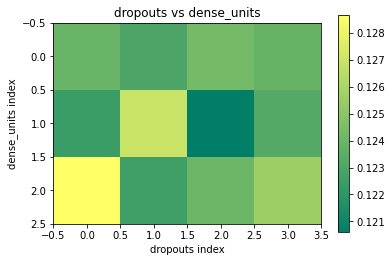

In [28]:
# # Using validation error
# visualize(d)

In [30]:
# %%capture capt

# vary_param = {'dense_units' : [[1000, 500, 100, 2], [800, 400, 80, 2], [500, 300, 50, 2]], 
#               'dropouts'    : [[0.7, 0.5, 0.2, 0], [0.5, 0.5, 0.2, 0],[0.5, 0.2, 0.2, 0], [0.2, 0.2, 0.2, 0]]
#              }


# d = vary_cfl_parameters(vary_param)

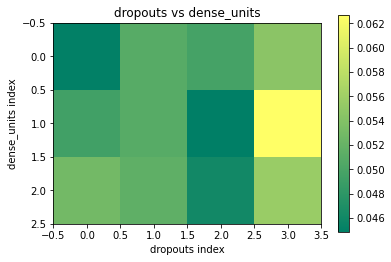

In [31]:
# # Using distribution error
# visualize(d)